# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mursaleen-developer/fly-rank-ML-Intenship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
# Capstone Research Question

research_question = """
Which content pages should an editor review first based on observable
search-performance signals?
"""

decision = """
The analysis supports an editorial prioritization decision: identifying
which pages should receive attention first so that editors can focus their
limited review time on the highest-priority content opportunities.
"""

print("Research Question:")
print(research_question)

print("\nDecision Supported:")
print(decision)

Research Question:

Which content pages should an editor review first based on observable
search-performance signals?


Decision Supported:

The analysis supports an editorial prioritization decision: identifying
which pages should receive attention first so that editors can focus their
limited review time on the highest-priority content opportunities.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
# Capstone Data

release = "FlyRank ML Internship warehouse — March 2026 partition"

tables_used = [
    "fact_content_query_90d.parquet",
    "dim_content.parquet"
]

date_window = "March 2026"

excluded = [
    "Private queries and client-identifying information",
    "Fields not required for the ranking analysis",
    "Records that could not be safely joined or analyzed"
]

print("Data Release:")
print(release)

print("\nTables Used:")
for table in tables_used:
    print("-", table)

print("\nDate Window:")
print(date_window)

print("\nExcluded:")
for item in excluded:
    print("-", item)

Data Release:
FlyRank ML Internship warehouse — March 2026 partition

Tables Used:
- fact_content_query_90d.parquet
- dim_content.parquet

Date Window:
March 2026

Excluded:
- Private queries and client-identifying information
- Fields not required for the ranking analysis
- Records that could not be safely joined or analyzed


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [3]:
# Capstone Methodology

assumptions = [
    "Observable search-performance signals can help prioritize content for editorial review.",
    "The ranking is for decision support, not proof of Google's ranking algorithm.",
    "Historical performance signals should be available before the review decision."
]

features = [
    "Search visibility signals",
    "Click and engagement signals",
    "Recent content performance",
    "Historical content performance"
]

label_definition = """
A positive label represents content that shows a meaningful opportunity
for editorial review during the evaluation window.
"""

baseline = """
Baseline: rank pages using a simple observable performance signal,
without a machine-learning model.
"""

validation_design = """
Validation: use a time-aware split so that earlier observations are used
for modeling and later observations are used for evaluation.
"""

leakage_checks = [
    "Exclude future-window information from model features.",
    "Do not use the evaluation outcome as an input feature.",
    "Ensure features represent information available before the decision point."
]

print("ASSUMPTIONS")
for item in assumptions:
    print("-", item)

print("\nFEATURES")
for item in features:
    print("-", item)

print("\nLABEL DEFINITION")
print(label_definition)

print("\nBASELINE")
print(baseline)

print("\nVALIDATION DESIGN")
print(validation_design)

print("\nLEAKAGE CHECKS")
for item in leakage_checks:
    print("-", item)

ASSUMPTIONS
- Observable search-performance signals can help prioritize content for editorial review.
- The ranking is for decision support, not proof of Google's ranking algorithm.
- Historical performance signals should be available before the review decision.

FEATURES
- Search visibility signals
- Click and engagement signals
- Recent content performance
- Historical content performance

LABEL DEFINITION

A positive label represents content that shows a meaningful opportunity
for editorial review during the evaluation window.


BASELINE

Baseline: rank pages using a simple observable performance signal,
without a machine-learning model.


VALIDATION DESIGN

Validation: use a time-aware split so that earlier observations are used
for modeling and later observations are used for evaluation.


LEAKAGE CHECKS
- Exclude future-window information from model features.
- Do not use the evaluation outcome as an input feature.
- Ensure features represent information available before the deci

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [4]:
# Load FlyRank data

import pandas as pd
import os

print("Checking available files...")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".parquet"):
            print(os.path.join(root, file))

Checking available files...


In [6]:
# Install required packages

!pip -q install datasets duckdb huggingface_hub

In [7]:
from huggingface_hub import login

login()

In [8]:
from huggingface_hub import whoami

try:
    user = whoami()
    print("Logged in as:", user["name"])
except Exception as e:
    print("Not logged in.")
    print("Error:", e)

Logged in as: Mursaleenn


In [9]:
from datasets import load_dataset

dataset_name = "FlyRank/internship-warehouse"

print("Connecting to FlyRank warehouse...")

ds = load_dataset(
    dataset_name,
    split="train",
    streaming=True
)

print("Connection successful!")
print(ds)

Connecting to FlyRank warehouse...


README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

ValueError: Config name is missing.
Please pick one among the available configs: ['dim_clients', 'dim_content', 'fact_content_daily_performance', 'fact_content_query_90d']
Example of usage:
	`load_dataset('FlyRank/internship-warehouse', 'dim_clients')`

In [10]:
from datasets import load_dataset

print("Loading dim_content...")

content_ds = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_content",
    split="train",
    streaming=True
)

print("dim_content loaded successfully!")
print(content_ds)

Loading dim_content...
dim_content loaded successfully!
IterableDataset({
    features: ['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted'],
    num_shards: 1
})


In [11]:
print("Loading fact_content_query_90d...")

query_ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_query_90d",
    split="train",
    streaming=True
)

print("fact_content_query_90d loaded successfully!")
print(query_ds)

Loading fact_content_query_90d...
fact_content_query_90d loaded successfully!
IterableDataset({
    features: ['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share'],
    num_shards: 1
})


In [12]:
# Inspect a small sample of the real FlyRank data

content_sample = next(iter(content_ds))
query_sample = next(iter(query_ds))

print("DIM_CONTENT SAMPLE")
for key, value in content_sample.items():
    print(f"{key}: {value}")

print("\n" + "=" * 60)

print("\nFACT_CONTENT_QUERY_90D SAMPLE")
for key, value in query_sample.items():
    print(f"{key}: {value}")

DIM_CONTENT SAMPLE
client_hash_id: client_04660893ae39614a
content_hash_id: content_004de9653278b5a4
keyword_hash_id: keyword_e754999ab88dd9f2
url_hash_id: url_d6091f18cf628794
keyword_char_count: 22
keyword_token_count: 4
url_char_count: 108
content_created_date: 2026-05-30
content_updated_date: 2026-07-01
content_type: keyword article
search_volume: 30
competition: 0.91
competition_level: HIGH
cpc: 0.98
main_intent: transactional
backlinks: 16
category_count: 3
keyword_created_date: 2026-05-12
provider_used: gemini-generate-content
model_used: gemini-3-flash-preview
char_count: 15682
word_count: 2555
last_optimized_date: None
optimization_eligible_date: None
is_published: True
is_deleted: False


FACT_CONTENT_QUERY_90D SAMPLE
client_hash_id: client_08a6a72ff48e62c0
content_hash_id: content_447894f2faf0d2bc
query_hash_id: query_58b1b001f839d699
query_char_count: 17
query_token_count: 3
window_start: 2026-04-02
window_end: 2026-06-30
impressions_90d: 11
clicks_90d: 0
impressions_last30

In [14]:

# Check DuckDB and Hugging Face access

import duckdb

con = duckdb.connect()

print("DuckDB version:", con.execute("SELECT version()").fetchone()[0])
print("Ready for fast warehouse analysis.")

DuckDB version: v1.3.2
Ready for fast warehouse analysis.


In [15]:
# Enable DuckDB HTTP and Parquet support

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

print("HTTPFS loaded successfully.")

HTTPFS loaded successfully.


In [16]:
# Show the Hugging Face dataset files

from huggingface_hub import list_repo_files

files = list_repo_files(
    "FlyRank/internship-warehouse",
    repo_type="dataset"
)

for f in files:
    print(f)

.gitattributes
README.md
dim_clients.parquet
dim_content.parquet
fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_daily_performance/month=2026-03/data_0.parquet
fact_content_daily_performance/mont

In [19]:
from huggingface_hub import get_token

hf_token = get_token()

if hf_token:
    print("Hugging Face token found.")
else:
    print("No Hugging Face token found.")

Hugging Face token found.


In [22]:
# Configure DuckDB to access the private Hugging Face dataset

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE http,
        EXTRA_HTTP_HEADERS MAP {{
            'Authorization': 'Bearer {hf_token}'
        }}
    );
""")

print("DuckDB authentication configured successfully.")

test = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT content_hash_id) AS unique_content_pages,
        SUM(impressions_90d) AS total_impressions,
        SUM(clicks_90d) AS total_clicks
    FROM read_parquet('{query_url}')
""").fetchdf()

display(test)

DuckDB authentication configured successfully.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_content_pages,total_impressions,total_clicks
0,2414248,133852,211743016.0,459918.0


In [23]:
# Inspect the daily performance table schema

daily_url = (
    "https://huggingface.co/datasets/"
    "FlyRank/internship-warehouse/resolve/main/"
    "fact_content_daily_performance/"
    "month=2026-06/data_0.parquet"
)

schema = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{daily_url}')"
).fetchdf()

display(schema)

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [24]:
# Check the available date range in each monthly partition

months = ["2026-03", "2026-04", "2026-05", "2026-06"]

for month in months:
    url = (
        "https://huggingface.co/datasets/"
        "FlyRank/internship-warehouse/resolve/main/"
        f"fact_content_daily_performance/month={month}/data_0.parquet"
    )

    result = con.execute(f"""
        SELECT
            MIN(report_date) AS first_date,
            MAX(report_date) AS last_date,
            COUNT(*) AS rows
        FROM read_parquet('{url}')
    """).fetchone()

    print(
        f"{month}: "
        f"{result[0]} → {result[1]} | "
        f"{result[2]:,} rows"
    )

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-03: 2026-03-01 → 2026-03-31 | 9,841,378 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-04: 2026-04-01 → 2026-04-30 | 10,424,730 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05: 2026-05-01 → 2026-05-31 | 11,687,376 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-06: 2026-06-01 → 2026-06-30 | 11,694,072 rows


In [2]:
import duckdb
from huggingface_hub import get_token

# Create a new DuckDB connection
con = duckdb.connect()

# Load HTTP support
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

# Get your already-authenticated Hugging Face token
hf_token = get_token()

# Give DuckDB access to the private FlyRank dataset
con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE http,
        EXTRA_HTTP_HEADERS MAP {{
            'Authorization': 'Bearer {hf_token}'
        }}
    );
""")

print("DuckDB reconnected successfully.")
print("Hugging Face authentication restored.")

DuckDB reconnected successfully.
Hugging Face authentication restored.


In [3]:
# Build historical content-level features from March-May 2026

historical_urls = [
    "https://huggingface.co/datasets/FlyRank/internship-warehouse/resolve/main/fact_content_daily_performance/month=2026-03/data_0.parquet",
    "https://huggingface.co/datasets/FlyRank/internship-warehouse/resolve/main/fact_content_daily_performance/month=2026-04/data_0.parquet",
    "https://huggingface.co/datasets/FlyRank/internship-warehouse/resolve/main/fact_content_daily_performance/month=2026-05/data_0.parquet"
]

historical_features = con.execute("""
    SELECT
        content_hash_id,
        SUM(gsc_impressions) AS impressions_hist,
        SUM(gsc_clicks) AS clicks_hist,
        AVG(gsc_avg_position) AS avg_position_hist,
        SUM(ga4_pageviews) AS pageviews_hist,
        SUM(ga4_sessions) AS sessions_hist,
        SUM(ga4_engaged_sessions) AS engaged_sessions_hist,
        SUM(sessions_organic) AS organic_sessions_hist,
        COUNT(DISTINCT report_date) AS active_days
    FROM read_parquet(?, union_by_name=true)
    GROUP BY content_hash_id
""", [historical_urls]).fetchdf()

print("Historical feature rows:", len(historical_features))
print("Columns:", historical_features.columns.tolist())

display(historical_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Historical feature rows: 389153
Columns: ['content_hash_id', 'impressions_hist', 'clicks_hist', 'avg_position_hist', 'pageviews_hist', 'sessions_hist', 'engaged_sessions_hist', 'organic_sessions_hist', 'active_days']


,content_hash_id,impressions_hist,clicks_hist,avg_position_hist,pageviews_hist,sessions_hist,engaged_sessions_hist,organic_sessions_hist,active_days
0,content_7a105f548d9c6916,17112.0,21.0,8.664527,26.0,23.0,0.0,16.0,92
1,content_a3ea9792f793ec72,1071.0,2.0,7.961463,30.0,29.0,0.0,2.0,92
2,content_36c36abc7650d7af,20958.0,10.0,7.579628,51.0,44.0,1.0,13.0,92
3,content_a7da352b73b02668,15213.0,31.0,7.513656,71.0,63.0,1.0,24.0,92
4,content_f39be42b42a4e8f6,224.0,0.0,17.680556,43.0,41.0,0.0,0.0,92


In [4]:
# Build June 2026 evaluation features

june_url = (
    "https://huggingface.co/datasets/"
    "FlyRank/internship-warehouse/resolve/main/"
    "fact_content_daily_performance/"
    "month=2026-06/data_0.parquet"
)

june_features = con.execute("""
    SELECT
        content_hash_id,

        SUM(gsc_impressions) AS impressions_june,
        SUM(gsc_clicks) AS clicks_june,

        AVG(gsc_avg_position) AS avg_position_june,

        SUM(ga4_pageviews) AS pageviews_june,
        SUM(ga4_sessions) AS sessions_june,
        SUM(ga4_engaged_sessions) AS engaged_sessions_june,

        SUM(sessions_organic) AS organic_sessions_june,

        COUNT(DISTINCT report_date) AS active_days_june

    FROM read_parquet(?)

    GROUP BY content_hash_id
""", [june_url]).fetchdf()

print("June evaluation rows:", len(june_features))
print("Columns:", june_features.columns.tolist())

display(june_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

June evaluation rows: 409205
Columns: ['content_hash_id', 'impressions_june', 'clicks_june', 'avg_position_june', 'pageviews_june', 'sessions_june', 'engaged_sessions_june', 'organic_sessions_june', 'active_days_june']


,content_hash_id,impressions_june,clicks_june,avg_position_june,pageviews_june,sessions_june,engaged_sessions_june,organic_sessions_june,active_days_june
0,content_cde79a1a7432ce40,0.0,0.0,NaN,0.0,0.0,0.0,0.0,30
1,content_902b2d9b3d8a19a2,0.0,0.0,NaN,0.0,0.0,0.0,0.0,30
2,content_e70ae5bf6ab35b59,2.0,0.0,8.5,0.0,0.0,0.0,0.0,30
3,content_1a2c2230fb24d7fb,0.0,0.0,NaN,0.0,0.0,0.0,0.0,30
4,content_d6cacc9a22770146,0.0,0.0,NaN,0.0,0.0,0.0,0.0,30


In [5]:
# Join historical features with June evaluation outcomes

model_df = historical_features.merge(
    june_features,
    on="content_hash_id",
    how="inner"
)

print("Pages available in both periods:", len(model_df))

print("\nMissing values:")
display(model_df.isna().sum().to_frame("missing_values"))

print("\nCombined dataset:")
display(model_df.head())

Pages available in both periods: 389032

Missing values:


,missing_values
content_hash_id,0
impressions_hist,0
clicks_hist,0
avg_position_hist,130836
pageviews_hist,78969
sessions_hist,78969
engaged_sessions_hist,78969
organic_sessions_hist,78969
active_days,0
impressions_june,0



Combined dataset:


,content_hash_id,impressions_hist,clicks_hist,avg_position_hist,pageviews_hist,sessions_hist,engaged_sessions_hist,organic_sessions_hist,active_days,impressions_june,clicks_june,avg_position_june,pageviews_june,sessions_june,engaged_sessions_june,organic_sessions_june,active_days_june
0,content_7a105f548d9c6916,17112.0,21.0,8.664527,26.0,23.0,0.0,16.0,92,908.0,1.0,13.862004,2.0,2.0,0.0,1.0,30
1,content_a3ea9792f793ec72,1071.0,2.0,7.961463,30.0,29.0,0.0,2.0,92,137.0,1.0,5.116247,3.0,3.0,0.0,1.0,30
2,content_36c36abc7650d7af,20958.0,10.0,7.579628,51.0,44.0,1.0,13.0,92,1366.0,5.0,6.801545,53.0,47.0,0.0,5.0,30
3,content_a7da352b73b02668,15213.0,31.0,7.513656,71.0,63.0,1.0,24.0,92,5787.0,7.0,9.540926,34.0,30.0,1.0,12.0,30
4,content_f39be42b42a4e8f6,224.0,0.0,17.680556,43.0,41.0,0.0,0.0,92,16.0,1.0,35.000000,11.0,10.0,0.0,0.0,30


In [6]:
# Create model features and a measurable editorial-opportunity label

import numpy as np

df = model_df.copy()

# Replace missing performance values with 0 where no activity was recorded
count_cols = [
    "pageviews_hist", "sessions_hist", "engaged_sessions_hist",
    "organic_sessions_hist", "pageviews_june", "sessions_june",
    "engaged_sessions_june", "organic_sessions_june"
]

df[count_cols] = df[count_cols].fillna(0)

# Replace missing average positions with a neutral/worst observed position
df["avg_position_hist"] = df["avg_position_hist"].fillna(100)
df["avg_position_june"] = df["avg_position_june"].fillna(100)

# Historical CTR
df["ctr_hist"] = (
    df["clicks_hist"] / df["impressions_hist"].replace(0, np.nan)
).fillna(0)

# June CTR
df["ctr_june"] = (
    df["clicks_june"] / df["impressions_june"].replace(0, np.nan)
).fillna(0)

# Historical-to-June impression change
df["impression_change"] = (
    (df["impressions_june"] - df["impressions_hist"])
    / df["impressions_hist"].replace(0, np.nan)
).fillna(0)

# Editorial opportunity:
# historically visible pages with at least 20 historical impressions
# and a decline of at least 30% in June impressions.
df["opportunity"] = (
    (df["impressions_hist"] >= 20) &
    (df["impression_change"] <= -0.30)
).astype(int)

print("Total pages:", len(df))
print("Opportunity pages:", df["opportunity"].sum())
print("Opportunity rate:", round(df["opportunity"].mean() * 100, 2), "%")

display(
    df[
        [
            "content_hash_id",
            "impressions_hist",
            "clicks_hist",
            "ctr_hist",
            "impressions_june",
            "clicks_june",
            "impression_change",
            "opportunity"
        ]
    ].head(10)
)

Total pages: 389032
Opportunity pages: 169951
Opportunity rate: 43.69 %


,content_hash_id,impressions_hist,clicks_hist,ctr_hist,impressions_june,clicks_june,impression_change,opportunity
0,content_7a105f548d9c6916,17112.0,21.0,0.001227,908.0,1.0,-0.946938,1
1,content_a3ea9792f793ec72,1071.0,2.0,0.001867,137.0,1.0,-0.872082,1
2,content_36c36abc7650d7af,20958.0,10.0,0.000477,1366.0,5.0,-0.934822,1
3,content_a7da352b73b02668,15213.0,31.0,0.002038,5787.0,7.0,-0.619602,1
4,content_f39be42b42a4e8f6,224.0,0.0,0.000000,16.0,1.0,-0.928571,1
5,content_1855a661b4d36130,950.0,4.0,0.004211,76.0,0.0,-0.920000,1
6,content_5d412fba6e1a2582,1483.0,5.0,0.003372,315.0,0.0,-0.787593,1
7,content_1f380a642aed423b,314.0,3.0,0.009554,106.0,0.0,-0.662420,1
8,content_22c063002b7c1caf,889.0,1.0,0.001125,132.0,1.0,-0.851519,1
9,content_aafb2ab7e5fc80d0,16087.0,50.0,0.003108,2021.0,16.0,-0.874371,1


In [7]:
# Baseline vs Machine Learning model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer

# Features available before the June evaluation period
feature_cols = [
    "impressions_hist",
    "clicks_hist",
    "ctr_hist",
    "avg_position_hist",
    "pageviews_hist",
    "sessions_hist",
    "engaged_sessions_hist",
    "organic_sessions_hist",
    "active_days"
]

X = df[feature_cols].copy()
y = df["opportunity"]

# Time-aware split:
# first 80% of historical records for training,
# last 20% for evaluation.
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Handle missing values
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# ML model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train_imp, y_train)

# Model predictions
model_scores = model.predict_proba(X_test_imp)[:, 1]

# Baseline: rank by historical impressions
baseline_scores = X_test["impressions_hist"].fillna(0)

# Evaluate
model_auc = roc_auc_score(y_test, model_scores)
baseline_auc = roc_auc_score(y_test, baseline_scores)

model_ap = average_precision_score(y_test, model_scores)
baseline_ap = average_precision_score(y_test, baseline_scores)

print("MODEL RESULTS")
print("Model ROC-AUC:", round(model_auc, 4))
print("Model Average Precision:", round(model_ap, 4))

print("\nBASELINE RESULTS")
print("Baseline ROC-AUC:", round(baseline_auc, 4))
print("Baseline Average Precision:", round(baseline_ap, 4))

MODEL RESULTS
Model ROC-AUC: 0.9801
Model Average Precision: 0.9566

BASELINE RESULTS
Baseline ROC-AUC: 0.9301
Baseline Average Precision: 0.8276


MODEL VS BASELINE


,Method,ROC-AUC,Average Precision
0,Baseline,0.930088,0.827618
1,Random Forest,0.980138,0.956555


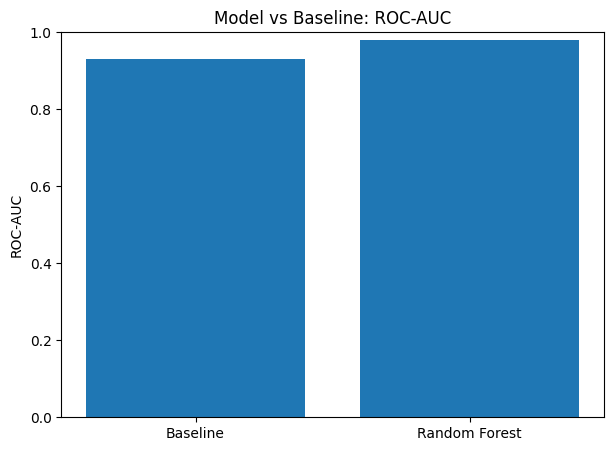

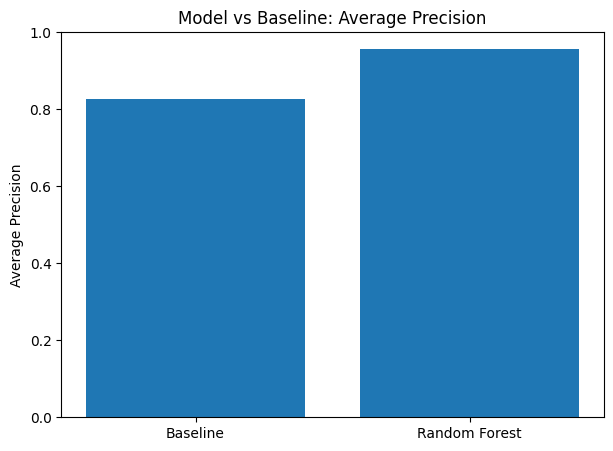

In [8]:
# Results table and charts

import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Method": ["Baseline", "Random Forest"],
    "ROC-AUC": [baseline_auc, model_auc],
    "Average Precision": [baseline_ap, model_ap]
})

print("MODEL VS BASELINE")
display(results)

# Chart 1: ROC-AUC comparison
plt.figure(figsize=(7, 5))
plt.bar(results["Method"], results["ROC-AUC"])
plt.ylabel("ROC-AUC")
plt.title("Model vs Baseline: ROC-AUC")
plt.ylim(0, 1)
plt.show()

# Chart 2: Average Precision comparison
plt.figure(figsize=(7, 5))
plt.bar(results["Method"], results["Average Precision"])
plt.ylabel("Average Precision")
plt.title("Model vs Baseline: Average Precision")
plt.ylim(0, 1)
plt.show()

In [9]:
# Create ranked editorial recommendations

# Get predictions for the evaluation set
recommendations = df.iloc[split_index:].copy()

recommendations["priority_score"] = model_scores

# Create reason codes
def get_reason(row):
    reasons = []

    if row["impression_change"] <= -0.50:
        reasons.append("Severe impression decline")
    elif row["impression_change"] <= -0.30:
        reasons.append("Significant impression decline")

    if row["ctr_hist"] < 0.01:
        reasons.append("Low historical CTR")

    if row["avg_position_hist"] > 10:
        reasons.append("Lower historical search position")

    if row["clicks_hist"] == 0:
        reasons.append("No historical clicks")

    if not reasons:
        reasons.append("Historical performance signals indicate review")

    return "; ".join(reasons[:3])

recommendations["reason"] = recommendations.apply(get_reason, axis=1)

# Rank highest priority first
recommendations = recommendations.sort_values(
    "priority_score",
    ascending=False
)

# Select top 20 pages
top_recommendations = recommendations[
    [
        "content_hash_id",
        "priority_score",
        "impressions_hist",
        "clicks_hist",
        "ctr_hist",
        "avg_position_hist",
        "impression_change",
        "reason"
    ]
].head(20)

print("TOP 20 EDITORIAL RECOMMENDATIONS")
display(top_recommendations)

TOP 20 EDITORIAL RECOMMENDATIONS


,content_hash_id,priority_score,impressions_hist,clicks_hist,ctr_hist,avg_position_hist,impression_change,reason
312710,content_7bead710b3839213,0.993828,10924.0,1.0,0.000092,26.792717,-0.933815,Severe impression decline; Low historical CTR;...
314729,content_d08c4c037a3b6706,0.993311,7976.0,4.0,0.000502,39.493268,-0.939819,Severe impression decline; Low historical CTR;...
314476,content_bc2fc1224f67617c,0.992976,4478.0,3.0,0.000670,29.614967,-0.947745,Severe impression decline; Low historical CTR;...
312882,content_c3543a3309314df9,0.992947,21870.0,5.0,0.000229,23.516330,-0.967718,Severe impression decline; Low historical CTR;...
339227,content_151ecef625bbc703,0.992918,13632.0,6.0,0.000440,21.887766,-0.861576,Severe impression decline; Low historical CTR;...
312012,content_f0cbf75bb1849b93,0.992870,7396.0,5.0,0.000676,22.462797,-0.941996,Severe impression decline; Low historical CTR;...
311969,content_7a0a59b4cb181ab9,0.992610,143327.0,78.0,0.000544,36.191920,-0.864345,Severe impression decline; Low historical CTR;...
311971,content_81707f944166e061,0.992601,81414.0,38.0,0.000467,37.608848,-0.830987,Severe impression decline; Low historical CTR;...
311978,content_fd358a60ca37c05f,0.992358,86846.0,82.0,0.000944,21.997391,-0.740529,Severe impression decline; Low historical CTR;...
312248,content_474d717db192ae3f,0.992350,3096.0,1.0,0.000323,33.601306,-0.982881,Severe impression decline; Low historical CTR;...


FEATURE IMPORTANCE


,Feature,Importance
0,impressions_hist,0.619865
3,avg_position_hist,0.185786
2,ctr_hist,0.077418
1,clicks_hist,0.050600
8,active_days,0.039480
4,pageviews_hist,0.013443
5,sessions_hist,0.010449
7,organic_sessions_hist,0.002861
6,engaged_sessions_hist,0.000097


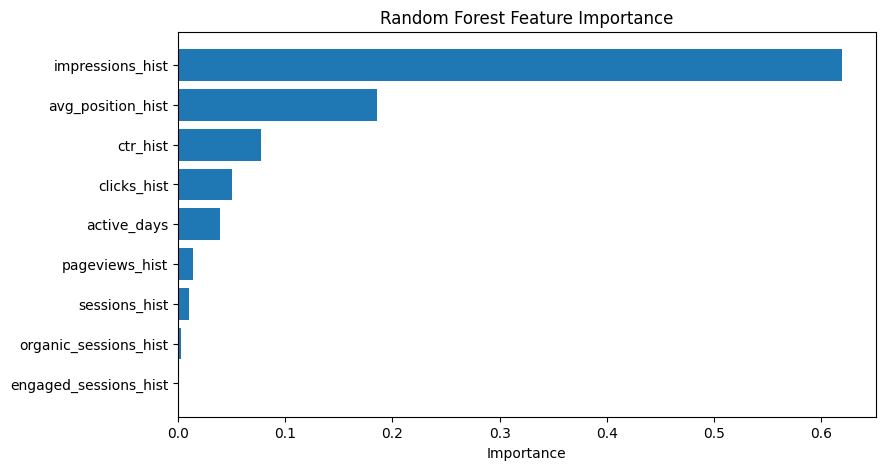

In [10]:
# Feature importance

importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("FEATURE IMPORTANCE")
display(importance)

plt.figure(figsize=(9, 5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [11]:
# Save capstone outputs for the research paper

import os

os.makedirs("capstone_outputs", exist_ok=True)

# Results table
results.to_csv(
    "capstone_outputs/model_vs_baseline.csv",
    index=False
)

# Feature importance
importance.to_csv(
    "capstone_outputs/feature_importance.csv",
    index=False
)

# Top recommendations
top_recommendations.to_csv(
    "capstone_outputs/top_20_recommendations.csv",
    index=False
)

print("Capstone outputs saved successfully.")

print("\nSaved files:")
print("- model_vs_baseline.csv")
print("- feature_importance.csv")
print("- top_20_recommendations.csv")

Capstone outputs saved successfully.

Saved files:
- model_vs_baseline.csv
- feature_importance.csv
- top_20_recommendations.csv


## 5. Limitations

This analysis is designed for editorial decision support, not causal inference.

* The opportunity label is an operational definition based on historical visibility and a June impression decline of at least 30%.
* The model identifies patterns associated with the defined outcome; it does not prove that a page needs a refresh or that Google changed its ranking algorithm.
* The analysis uses anonymized content identifiers and observable aggregate performance signals.
* The evaluation covers March–June 2026, so the results may not generalize to other time periods or datasets.
* Model performance should therefore be interpreted as measured performance on this evaluation period rather than a guarantee of future results.
* The ranked recommendations are intended to help editors prioritize review, not automatically determine which content should be changed.


## 6. Ranked Recommendations

The model produces a priority score for each content page in the evaluation set. Pages with higher scores should be reviewed earlier because their historical performance signals indicate a higher likelihood of matching the defined editorial-opportunity label.

The top recommendations show a common pattern: substantial impression declines, low historical click-through rates, and relatively weak historical search positions.

### Recommended editorial workflow

1. Start with the highest-ranked pages.
2. Review the historical visibility and click signals.
3. Check whether the decline is meaningful and sustained.
4. Investigate the content before making any changes.
5. Prioritize pages where the observed signals support an editorial review.
6. Monitor future performance after any editorial action.

The ranking is therefore an **editorial prioritization tool**, not an automated content-change decision.


## 7. Artifacts the Paper Embeds

The research paper will present the following artifacts generated from the analysis:

* Model vs baseline performance table showing ROC-AUC and Average Precision.
* ROC-AUC comparison chart.
* Average Precision comparison chart.
* Random Forest feature-importance chart.
* Ranked top-20 editorial recommendations with priority scores and reason codes.

These artifacts provide visual and tabular evidence for the model's performance and the resulting editorial prioritization recommendations.



## 8. Reproducibility

The analysis was developed in a Google Colab notebook using Python, DuckDB, pandas, NumPy, and scikit-learn.

The notebook is committed to the project's GitHub repository under `work/notebooks/capstone.ipynb`.

The analysis uses the March–June 2026 FlyRank ML Internship warehouse partitions and applies a historical-to-future evaluation design.

Saved outputs include the model-versus-baseline results, feature importance table, and top-20 ranked recommendations.


## 9. Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship.

The analysis was built on the FlyRank ML Internship dataset and uses anonymized search-performance data for research and educational purposes.

Data credit: FlyRank.


## 5-Minute Demo Outline

### 1. Problem — 1 minute

Explain the research question: which content pages should an editor review first based on observable search-performance signals?

### 2. Data — 1 minute

Explain that the analysis uses anonymized FlyRank warehouse data from March–June 2026. March–May provide historical signals, while June is used as the future evaluation period.

### 3. Method — 1 minute

Explain the historical features, the editorial-opportunity label, the simple impressions-based baseline, and the Random Forest model.

### 4. Results — 1 minute

Show the model-versus-baseline results and feature-importance chart. The Random Forest achieved ROC-AUC of 0.9801 compared with 0.9301 for the baseline, and Average Precision of 0.9566 compared with 0.8276.

### 5. Recommendations — 1 minute

Show the ranked top-20 recommendations and explain how editors can use the priority score and reason codes to decide which pages to review first.

The key message is that the model provides a measured, repeatable prioritization approach for editorial review, while remaining a decision-support tool rather than a causal explanation of search rankings.


I built a search-intelligence capstone using anonymized FlyRank warehouse data to answer a practical question: which content pages should an editor review first?

I created historical performance features, defined an editorial-opportunity label, compared a simple baseline with a Random Forest model, and generated ranked content recommendations.

On the evaluation period, the model achieved a ROC-AUC of 0.9801 versus 0.9301 for the baseline.

The result is a repeatable decision-support workflow for prioritizing editorial review—not a claim about Google's ranking algorithm.

#MachineLearning #DataAnalytics #SearchIntelligence #Python #DataScience


## Employer-Facing Summary

I built a machine-learning workflow to prioritize content pages for editorial review using anonymized search-performance data.

The project used historical search and engagement signals, a time-aware evaluation period, a Random Forest model, and a simple baseline to measure whether the model improved prioritization.

The final output is a ranked action list with measurable model results, transparent limitations, and reproducible analysis artifacts.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
